# Data Preprocessing 

This notebook uses the insights derived from EDA to preprocess the Bank Marketing dataset, split the data, and upload the dataset to HuggingFace.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

from imblearn.over_sampling import SMOTE

In [45]:
path = os.path.join(os.getcwd(), "..", "..", "datasets", "bank-additional-full.csv")
df = pd.read_csv(path, sep=";")

### remove duplicates

In [46]:
df.drop_duplicates(inplace=True)

### Categorical Features

#### replace null values with mode

In [47]:
df.replace("unknown", np.nan, inplace=True)
df.replace("nonexistent", np.nan, inplace=True)

#### remove `poutcome`

In [48]:
df.drop(columns=["poutcome"], inplace=True)

In [49]:
cat_features = df.select_dtypes(include=["object"]).columns.tolist()
df[cat_features].isna().mean() * 100

job             0.801438
marital         0.194288
education       4.201477
default        20.876239
housing         2.404313
loan            2.404313
contact         0.000000
month           0.000000
day_of_week     0.000000
y               0.000000
dtype: float64

In [50]:
# replace nan values with mode
for col in cat_features:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\BIG BOX\AppData\Local\Temp\ipykernel_21396\4025623126.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


### Numerical Features

#### remove `previous` and `pdays`

In [51]:
df.drop(columns=["previous", "pdays"], inplace=True)

#### remove outliers

In [52]:
outlier_var = ["age", "duration", "campaign", "cons.conf.idx"]
for var in outlier_var:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[var] = np.where(df[var] < lower_bound, lower_bound, df[var])
    df[var] = np.where(df[var] > upper_bound, upper_bound, df[var])

__________________________________________________________________________________________


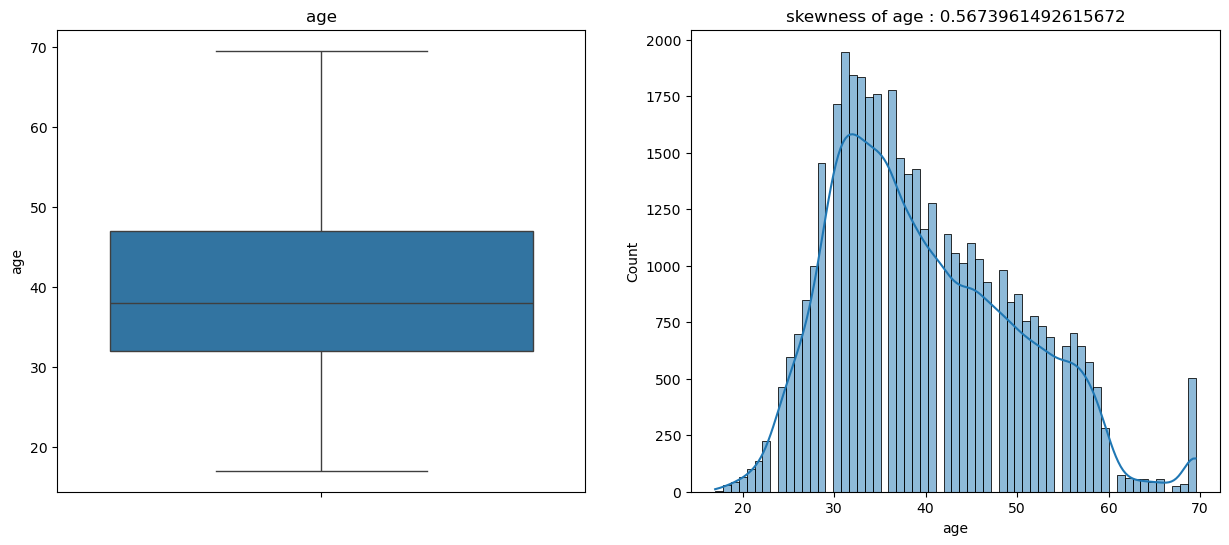

__________________________________________________________________________________________


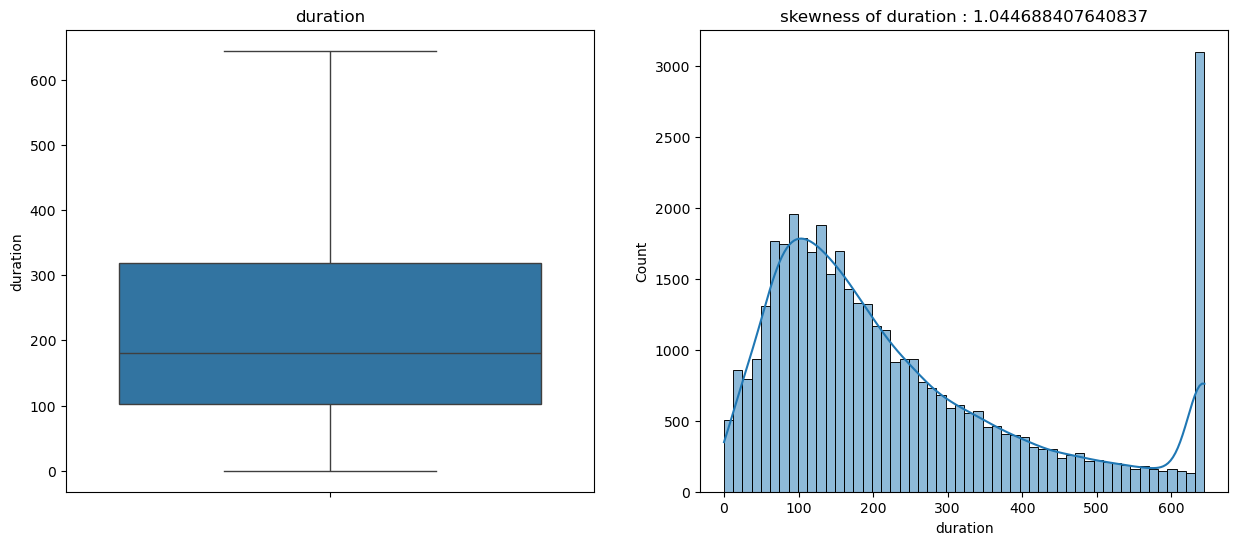

__________________________________________________________________________________________


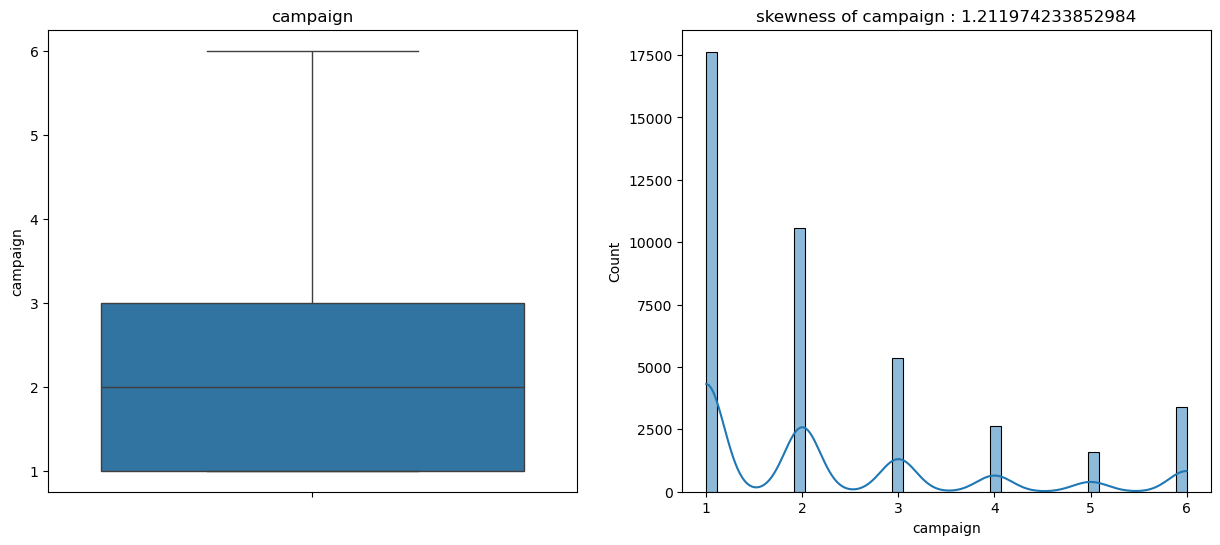

__________________________________________________________________________________________


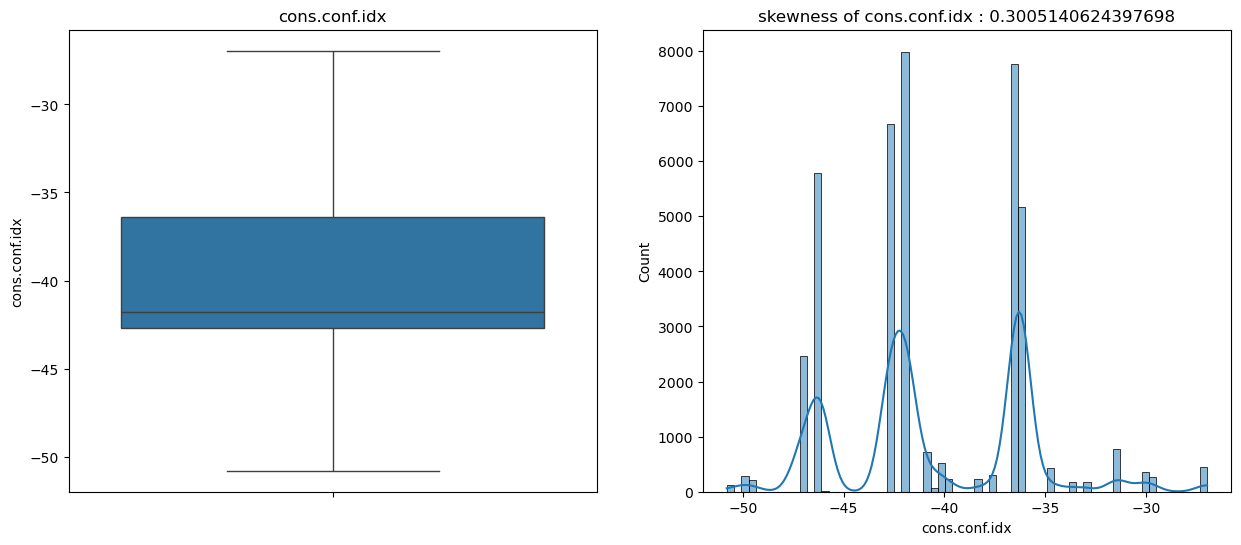

In [53]:
for var in outlier_var:
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    ax = sns.boxplot(data=df[var])
    ax.set_title(f"{var}")
    ax.set_ylabel(var)

    plt.subplot(1, 2, 2)
    ax = sns.histplot(data=df[var], kde=True)
    ax.set_title(f"skewness of {var} : {df[var].skew()}")
    ax.set_xlabel(var)
    print("__" * 45)
    plt.show()

### Label Encoding


In [54]:
cat_features = df.select_dtypes(include=["object"]).columns.tolist()
cat_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'y']

`marital`

In [55]:
df["marital"].value_counts()

marital
married     25001
single      11564
divorced     4611
Name: count, dtype: int64

merge single and divorced

In [56]:
df["marital"] = df["marital"].replace({"married": 1, "single": 0, "divorced": 0})

C:\Users\BIG BOX\AppData\Local\Temp\ipykernel_21396\3054817460.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["marital"]=df["marital"].replace({'married':1, 'single':0, 'divorced':0})


`education`

In [57]:
df["education"].value_counts()

education
university.degree      13894
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
illiterate                18
Name: count, dtype: int64

In [58]:
df["education"] = df["education"].replace(
    {
        "university.degree": 1,
        "professional.course": 2,
        "high.school": 3,
        "basic.9y": 4,
        "basic.6y": 5,
        "basic.4y": 6,
        "illiterate": 7,
    }
)

C:\Users\BIG BOX\AppData\Local\Temp\ipykernel_21396\3245203258.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["education"]=df["education"].replace({


`default`

In [59]:
df["default"].value_counts(normalize=True) * 100

default
no     99.992714
yes     0.007286
Name: proportion, dtype: float64

- remove `default`

In [60]:
df.drop(columns=["default"], inplace=True)

`housing`

In [61]:
df["housing"].value_counts()

housing
yes    22561
no     18615
Name: count, dtype: int64

In [62]:
df["housing"] = df["housing"].replace({"yes": 1, "no": 0})

C:\Users\BIG BOX\AppData\Local\Temp\ipykernel_21396\1500137444.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["housing"]=df["housing"].replace({'yes':1, 'no':0})


`loan`

In [63]:
df["loan"].value_counts()

loan
no     34928
yes     6248
Name: count, dtype: int64

In [64]:
df["loan"] = df["loan"].replace({"yes": 1, "no": 0})

C:\Users\BIG BOX\AppData\Local\Temp\ipykernel_21396\2370133446.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["loan"]=df["loan"].replace({'yes':1, 'no':0})


`class`

In [65]:
df["y"] = df["y"].replace({"yes": 1, "no": 0})

C:\Users\BIG BOX\AppData\Local\Temp\ipykernel_21396\513288557.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["y"]=df["y"].replace({'yes':1, 'no':0})


### Cyclic encoding

`month`

In [66]:
df["month"].value_counts()

month
may    13767
jul     7169
aug     6176
jun     5318
nov     4100
apr     2631
oct      717
sep      570
mar      546
dec      182
Name: count, dtype: int64

In [67]:
def cyclic_encode_str(df, col, string_map, period):
    """
    Map string values to integers, then apply cyclic encoding.
    Adds {col}_sin and {col}_cos columns to df.
    """
    numeric = df[col].str.lower().map(string_map)

    if numeric.isna().any():
        bad = df[col][numeric.isna()].unique().tolist()
        raise ValueError(f"Unrecognized values in '{col}': {bad}")

    x = numeric / period
    df[f"{col}_sin"] = np.sin(2 * np.pi * x)
    df[f"{col}_cos"] = np.cos(2 * np.pi * x)
    return df

In [68]:
# cyclic encoding for month
month_mapping = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}

df = cyclic_encode_str(df, "month", month_mapping, 12)
df.drop(columns=["month"], inplace=True)

`day_of_week`

In [69]:
df["day_of_week"].value_counts()

day_of_week
thu    8618
mon    8512
wed    8134
tue    8086
fri    7826
Name: count, dtype: int64

In [70]:
day_mapping = {"mon": 1, "tue": 2, "wed": 3, "thu": 4, "fri": 5}
df = cyclic_encode_str(df, "day_of_week", day_mapping, 5)
df.drop(columns=["day_of_week"], inplace=True)

#### One Hot Encoding

`job`

In [71]:
df["job"].value_counts()

job
admin.           10749
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
Name: count, dtype: int64

In [72]:
df = pd.get_dummies(df, columns=["job"], drop_first=False)

`contact`

In [73]:
df = pd.get_dummies(df, columns=["contact"], drop_first=False)

In [74]:
# change all the boolean columns to int
df = df.astype({col: "int64" for col in df.select_dtypes(include=["bool"]).columns})

#### features with higher correlation with the target 

In [75]:
# show the most correlated features to the target(without plot)
correlations = df.corr()["y"].abs().sort_values(ascending=False)
print(correlations)

y                    1.000000
duration             0.401306
nr.employed          0.354669
euribor3m            0.307740
emp.var.rate         0.298289
contact_telephone    0.144774
contact_cellular     0.144774
cons.price.idx       0.136134
month_cos            0.109494
job_student          0.093962
job_retired          0.092364
job_blue-collar      0.074431
campaign             0.069397
education            0.055147
cons.conf.idx        0.054713
marital              0.043044
job_services         0.032262
job_admin.           0.030953
month_sin            0.021379
age                  0.020918
day_of_week_sin      0.018293
job_entrepreneur     0.016651
job_unemployed       0.014749
day_of_week_cos      0.011889
housing              0.011145
job_housemaid        0.006510
job_technician       0.006069
job_self-employed    0.004668
loan                 0.004478
job_management       0.000426
Name: y, dtype: float64


remove `emp.var.rate` and `euribor3m` and keep `nr.employed`

In [76]:
df.drop(columns=["emp.var.rate", "euribor3m"], inplace=True)

### Feature Selection

In [77]:
importance = mutual_info_classif(
    df.drop(columns=["y"]), df["y"], discrete_features="auto", random_state=42
)
feature_importance = pd.Series(
    importance, index=df.drop(columns=["y"]).columns
).sort_values(ascending=False)
print(feature_importance)

duration             0.074160
cons.price.idx       0.070685
cons.conf.idx        0.068306
nr.employed          0.066460
month_cos            0.026457
month_sin            0.021760
contact_cellular     0.018469
contact_telephone    0.015608
age                  0.012154
education            0.006982
housing              0.006141
marital              0.005899
job_blue-collar      0.004361
job_student          0.003751
day_of_week_cos      0.003552
job_retired          0.002687
campaign             0.002370
job_management       0.002173
job_services         0.001244
job_housemaid        0.000360
loan                 0.000000
job_entrepreneur     0.000000
job_self-employed    0.000000
job_admin.           0.000000
job_technician       0.000000
job_unemployed       0.000000
day_of_week_sin      0.000000
dtype: float64


drop features with low MI

In [78]:
feat_drop = [
    "loan",
    "job_entrepreneur",
    "job_self-employed",
    "job_admin.",
    "job_technician",
    "job_unemployed",
    "day_of_week_sin",
]
df.drop(columns=feat_drop, inplace=True)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                41176 non-null  float64
 1   marital            41176 non-null  int64  
 2   education          41176 non-null  int64  
 3   housing            41176 non-null  int64  
 4   duration           41176 non-null  float64
 5   campaign           41176 non-null  float64
 6   cons.price.idx     41176 non-null  float64
 7   cons.conf.idx      41176 non-null  float64
 8   nr.employed        41176 non-null  float64
 9   y                  41176 non-null  int64  
 10  month_sin          41176 non-null  float64
 11  month_cos          41176 non-null  float64
 12  day_of_week_cos    41176 non-null  float64
 13  job_blue-collar    41176 non-null  int64  
 14  job_housemaid      41176 non-null  int64  
 15  job_management     41176 non-null  int64  
 16  job_retired        41176 no

### Train/Test Split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["y"]), df["y"], test_size=0.2, random_state=42
)

### MaxMinScaler

In [81]:
num_features = [
    "duration",
    "age",
    "campaign",
    "cons.conf.idx",
    "cons.price.idx",
    "nr.employed",
]
scaler = MinMaxScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

X_train.head()

,age,marital,education,housing,duration,campaign,cons.price.idx,cons.conf.idx,nr.employed,month_sin,month_cos,day_of_week_cos,job_blue-collar,job_housemaid,job_management,job_retired,job_services,job_student,contact_cellular,contact_telephone
12348,0.228571,1,5,1,0.443755,0.4,0.669135,0.339623,1.000000,-5.000000e-01,-0.866025,1.000000,0,0,0,0,0,0,0,1
8565,0.628571,0,1,0,0.276183,1.0,0.882307,0.377358,1.000000,1.224647e-16,-1.000000,-0.809017,0,0,0,0,0,0,0,1
21424,0.228571,0,1,0,0.159814,0.6,0.484412,0.616352,1.000000,-8.660254e-01,-0.500000,-0.809017,0,0,0,0,0,0,1,0
3316,0.342857,0,1,0,0.209465,0.0,0.698753,0.603774,0.859735,5.000000e-01,-0.866025,0.309017,0,0,0,0,0,0,0,1
33246,0.438095,0,3,0,0.648565,0.0,0.269680,0.192872,0.512287,5.000000e-01,-0.866025,-0.809017,1,0,0,0,0,0,1,0


### Handling Imbalance

In [82]:
sm = SMOTE(sampling_strategy=0.5, random_state=0)
X_train, y_train = sm.fit_resample(X_train, y_train)
X_train.shape

(43908, 20)

### Pytorch Dataset

In [83]:
def to_tensors(X: pd.DataFrame, y: np.ndarray):
    X_t = torch.tensor(X.to_numpy(), dtype=torch.float32)
    y_t = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(1)
    return X_t, y_t


X_tr, y_tr = to_tensors(X_train, y_train)
X_te, y_te = to_tensors(X_test, y_test)

BATCH_SIZE = 256
train_loader = DataLoader(
    TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(TensorDataset(X_te, y_te), batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Train batches: 172  |  Test batches: 33


### Upload to Hugging Face

In [84]:
from datasets import Dataset


def save_to_hf(X_train, X_test, y_train, y_test, repo_name):

    # Convert y to DataFrame
    y_train_df = pd.DataFrame(y_train, columns=["y"])
    y_test_df = pd.DataFrame(y_test, columns=["y"])

    # Combine X and y
    train_df = pd.concat([X_train, y_train_df], axis=1).reset_index(drop=True)
    test_df = pd.concat([X_test, y_test_df], axis=1).reset_index(drop=True)

    # Convert to HF Dataset
    train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
    test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

    # Push to Hugging Face Hub
    train_dataset.push_to_hub(repo_name, split="train")
    test_dataset.push_to_hub(repo_name, split="test")

    print("Uploaded dataset to Hugging Face:")
    print(repo_name)
    print("Train shape:", train_df.shape)
    print("Test shape:", test_df.shape)

In [ ]:
from huggingface_hub import login

login()

In [87]:
from huggingface_hub import HfApi

api = HfApi()
repo_name = "narimanee/bank-marketing-federated"

# Delete the repo entirely (removes the broken LFS pointer)
api.delete_repo(repo_id=repo_name, repo_type="dataset")

# Recreate it fresh
api.create_repo(repo_id=repo_name, repo_type="dataset", private=False)
print("Repo recreated ✓")

Repo recreated ✓


In [88]:
save_to_hf(
    X_train, X_test, y_train, y_test, repo_name="narimanee/bank-marketing-federated"
)

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded dataset to Hugging Face:
narimanee/bank-marketing-federated
Train shape: (43908, 21)
Test shape: (8236, 21)
